In [2]:
from pathlib import Path
import json
import pandas as pd

PROJECT_ROOT =  Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

json_file = RAW_DATA_DIR / "games.json"

with open(json_file, "r", encoding="utf-8") as f:
    games = json.load(f)

print(f"Loaded {len(games):,} games")

Loaded 135,140 games


In [3]:
records = []

for appid, game in games.items():
    row = game.copy()
    row["appid"] = int(appid)
    records.append(row)

df = pd.DataFrame(records)

df.head()

,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,...,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,appid
0,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,,,,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 0,0,0,0,0,0,0,[],2539430
1,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,...,3,0 - 20000,8,0,8,0,65,0,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",496350
2,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,...,3,0 - 20000,0,0,0,0,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...",1034400
3,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 20000,0,0,0,0,0,1,[],3292190
4,Maze Quest VR,"Apr 24, 2025",0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 20000,0,0,0,0,0,0,[],3631080


In [4]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = df["release_date"].dt.year

df[["name", "release_date", "release_year"]].head()

,name,release_date,release_year
0,Black Dragon Mage Playtest,2023-08-01,2023
1,Supipara - Chapter 1 Spring Has Come!,2016-07-29,2016
2,Mystery Solitaire The Black Raven,2019-05-06,2019
3,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,2024
4,Maze Quest VR,2025-04-24,2025


In [19]:
import pandas as pd

current_year = 2026

games_per_year = (
    df[
        (df["release_year"] >= 2010)
        & (df["release_year"] <= current_year)
    ]
    .groupby("release_year")
    .size()
    .reset_index(name="actual_games")
)

games_per_year

,release_year,actual_games
0,2010,255
1,2011,260
2,2012,322
3,2013,468
4,2014,1524
5,2015,2517
6,2016,4143
7,2017,5927
8,2018,7461
9,2019,7245


In [20]:
# Use only completed years for the growth calculation
recent = games_per_year[
    games_per_year["release_year"].between(2022, 2025)
].copy()

# Calculate year-over-year percentage growth
recent["growth_rate"] = recent["actual_games"].pct_change()

# Average the completed annual growth rates
average_growth_rate = recent["growth_rate"].dropna().mean()

# Use 2025 as the base for the 2026 estimate
previous_year_total = int(
    games_per_year.loc[
        games_per_year["release_year"] == 2025,
        "actual_games"
    ].iloc[0]
)

projected_total = round(
    previous_year_total * (1 + average_growth_rate)
)

actual_current_year = int(
    games_per_year.loc[
        games_per_year["release_year"] == current_year,
        "actual_games"
    ].iloc[0]
)

projected_remaining = max(
    projected_total - actual_current_year,
    0
)

print(recent)
print()
print(f"Average annual growth: {average_growth_rate:.2%}")
print(f"{current_year} released so far: {actual_current_year:,}")
print(f"{current_year} estimated total: {projected_total:,}")
print(f"Estimated remaining releases: {projected_remaining:,}")

    release_year  actual_games  growth_rate
12          2022         12288          NaN
13          2023         14603     0.188395
14          2024         20042     0.372458
15          2025         24976     0.246183

Average annual growth: 26.90%
2026 released so far: 12,564
2026 estimated total: 31,695
Estimated remaining releases: 19,131


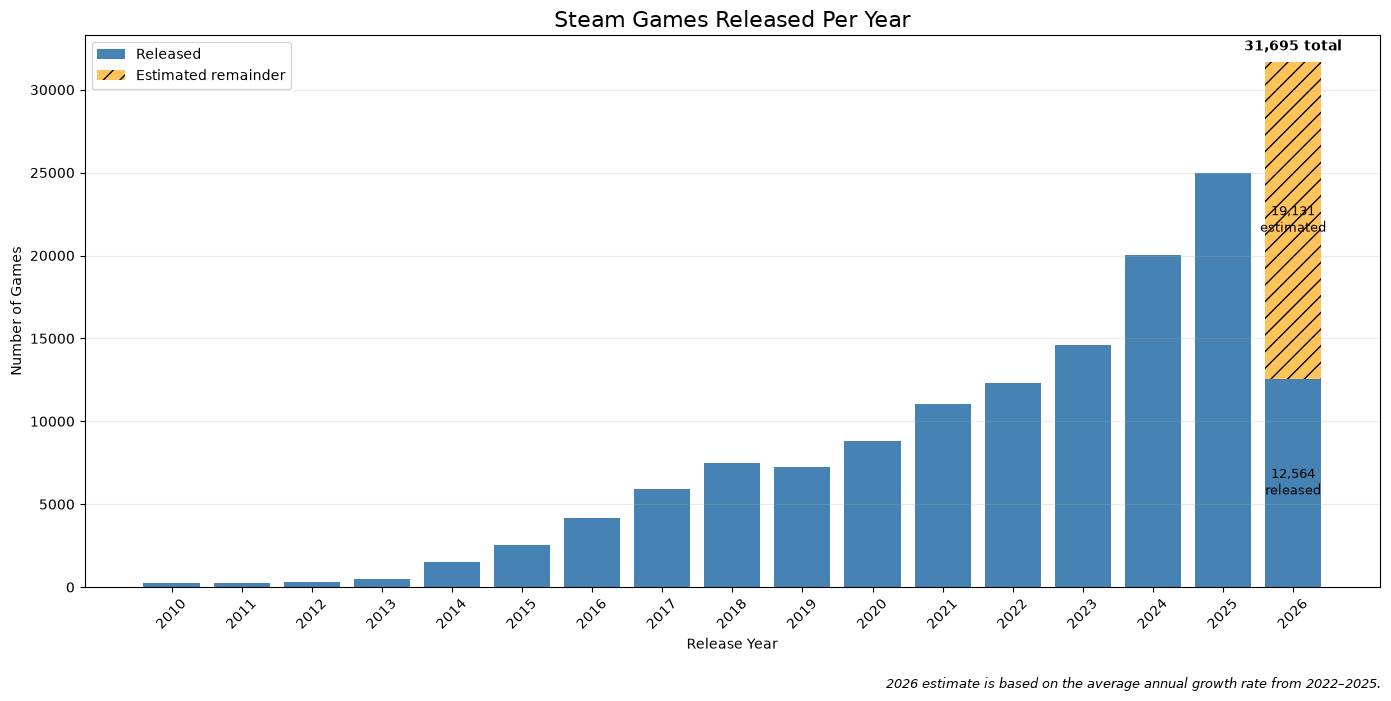

In [21]:
import matplotlib.pyplot as plt

# Start with no projected portion for any year
games_per_year["projected_games"] = 0

# Add the estimated remainder only to 2026
games_per_year.loc[
    games_per_year["release_year"] == current_year,
    "projected_games"
] = projected_remaining

fig, ax = plt.subplots(figsize=(14, 7))

# Actual releases
ax.bar(
    games_per_year["release_year"],
    games_per_year["actual_games"],
    color="steelblue",
    label="Released"
)

# Estimated remainder stacked above actual 2026 releases
ax.bar(
    games_per_year["release_year"],
    games_per_year["projected_games"],
    bottom=games_per_year["actual_games"],
    color="orange",
    alpha=0.65,
    hatch="//",
    label="Estimated remainder"
)

ax.set_title(
    "Steam Games Released Per Year",
    fontsize=16
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Games")

ax.set_xticks(games_per_year["release_year"])
ax.tick_params(axis="x", rotation=45)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend()

# Label the actual and estimated parts of the 2026 bar
ax.text(
    current_year,
    actual_current_year / 2,
    f"{actual_current_year:,}\nreleased",
    ha="center",
    va="center",
    fontsize=9
)

ax.text(
    current_year,
    actual_current_year + projected_remaining / 2,
    f"{projected_remaining:,}\nestimated",
    ha="center",
    va="center",
    fontsize=9
)

# Show the estimated full-year total above the 2026 bar
ax.text(
    current_year,
    projected_total + projected_total * 0.015,
    f"{projected_total:,} total",
    ha="center",
    va="bottom",
    fontweight="bold"
)

fig.text(
    0.99,
    0.01,
    (
        "2026 estimate is based on the average annual "
        "growth rate from 2022–2025."
    ),
    ha="right",
    fontsize=9,
    style="italic"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [23]:
yearly_table = (
    df.dropna(subset=["release_year"])
    .groupby("release_year")
    .size()
    .reset_index(name="Games")
    .sort_values("release_year")
)

# Calculate YoY growth before filtering out earlier years
yearly_table["YoY Growth"] = yearly_table["Games"].pct_change()

# Keep only 2010 onward for display
yearly_table = yearly_table[
    yearly_table["release_year"] >= 2010
].copy()

yearly_table = yearly_table.rename(
    columns={"release_year": "Year"}
)

yearly_table["Status"] = "Actual"

# Replace incomplete 2026 value with projected full-year total
yearly_table.loc[
    yearly_table["Year"] == current_year,
    "Games"
] = projected_total

yearly_table.loc[
    yearly_table["Year"] == current_year,
    "Status"
] = "Estimated"

# Recalculate 2026 growth using the projected total
previous_year_games = yearly_table.loc[
    yearly_table["Year"] == current_year - 1,
    "Games"
].iloc[0]

yearly_table.loc[
    yearly_table["Year"] == current_year,
    "YoY Growth"
] = projected_total / previous_year_games - 1

yearly_table = yearly_table[
    ["Year", "Games", "YoY Growth", "Status"]
]

yearly_table

,Year,Games,YoY Growth,Status
13,2010,255,-0.205607,Actual
14,2011,260,0.019608,Actual
15,2012,322,0.238462,Actual
16,2013,468,0.453416,Actual
17,2014,1524,2.256410,Actual
18,2015,2517,0.651575,Actual
19,2016,4143,0.646007,Actual
20,2017,5927,0.430606,Actual
21,2018,7461,0.258816,Actual
22,2019,7245,-0.028951,Actual


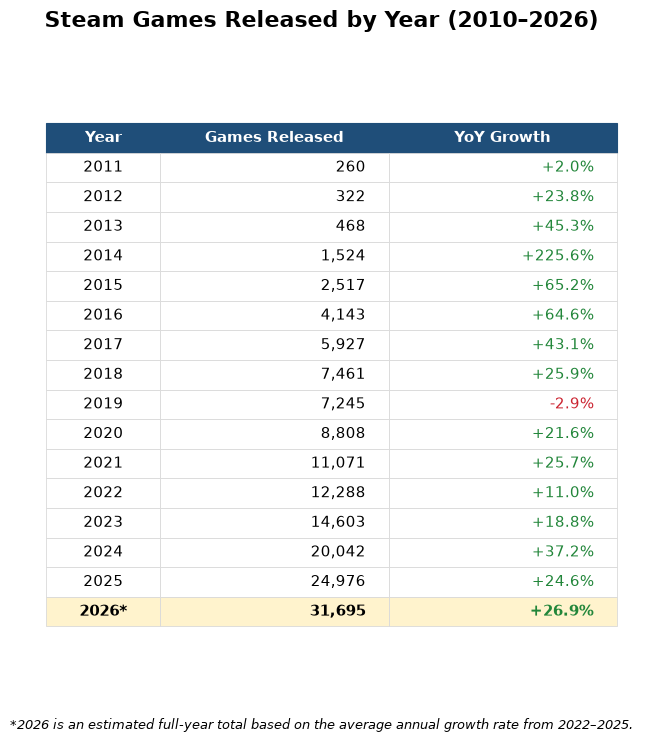

Saved to: d:\Workstation\python\steam-analysis\outputs\tables\steam_games_by_year.png


In [28]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


# ----------------------------
# Prepare display table
# ----------------------------

image_table = yearly_table[
    yearly_table["Year"] >= 2011
][["Year", "Games", "YoY Growth"]].copy()

# Preserve numeric growth values for coloring later
growth_values = image_table["YoY Growth"].copy()

# Convert Year to string before adding an asterisk
image_table["Year"] = (
    image_table["Year"]
    .astype(int)
    .astype(str)
)

image_table.loc[
    image_table["Year"] == str(current_year),
    "Year"
] = f"{current_year}*"

# Format values for display
image_table["Games"] = image_table["Games"].map(
    lambda value: f"{int(round(value)):,}"
)

image_table["YoY Growth"] = image_table["YoY Growth"].map(
    lambda value: "—" if pd.isna(value) else f"{value:+.1%}"
)

# ----------------------------
# Create figure
# ----------------------------

row_count = len(image_table)

fig, ax = plt.subplots(
    figsize=(8, row_count * 0.4 + 1.2)
)

ax.axis("off")

table = ax.table(
    cellText=image_table.values,
    colLabels=[
        "Year",
        "Games Released",
        "YoY Growth"
    ],
    cellLoc="center",
    colLoc="center",
    bbox=[0.04, 0.07, 0.92, 0.86],
    colWidths=[0.20, 0.40, 0.40]
)

table.auto_set_font_size(False)
table.set_fontsize(11)

# ----------------------------
# Style cells
# ----------------------------

for (row, column), cell in table.get_celld().items():

    if row == 0:
        cell.set_facecolor("#1f4e79")
        cell.set_text_props(
            color="white",
            weight="bold"
        )
        cell.set_edgecolor("#1f4e79")
        cell.set_linewidth(0.8)

    else:
        cell.set_facecolor("white")
        cell.set_edgecolor("#d9d9d9")
        cell.set_linewidth(0.6)

        displayed_year = image_table.iloc[row - 1]["Year"]

        # Highlight projected year
        if displayed_year == f"{current_year}*":
            cell.set_facecolor("#fff3cd")
            cell.set_text_props(weight="bold")

# Right-align numeric columns
for row in range(1, row_count + 1):
    table[(row, 1)].get_text().set_ha("right")
    table[(row, 2)].get_text().set_ha("right")

# Color growth values
for row, growth in enumerate(growth_values, start=1):

    if pd.isna(growth):
        continue

    if growth > 0:
        table[(row, 2)].get_text().set_color("#22863a")

    elif growth < 0:
        table[(row, 2)].get_text().set_color("#cb2431")

# ----------------------------
# Title and footnote
# ----------------------------

fig.suptitle(
    f"Steam Games Released by Year (2010–{current_year})",
    fontsize=16,
    fontweight="bold",
    y=0.975
)

fig.text(
    0.5,
    0.025,
    (
        f"*{current_year} is an estimated full-year total based on "
        "the average annual growth rate from 2022–2025."
    ),
    ha="center",
    va="bottom",
    fontsize=9,
    style="italic"
)

# ----------------------------
# Save image
# ----------------------------

output_dir = PROJECT_ROOT / "outputs" / "tables"
output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = output_dir / "steam_games_by_year.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    pad_inches=0.08
)

plt.show()

print(f"Saved to: {output_path}")

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Estimated number of owners/sales per Steam review
REVIEW_MULTIPLIER = 45

# Years to include
START_YEAR = 2022
END_YEAR = 2025

# Number of tags retained per year
TOP_N = 10

In [30]:
games_revenue = df.copy()

# Ensure required numeric columns are numeric
numeric_columns = [
    "positive",
    "negative",
    "price",
    "release_year"
]

for column in numeric_columns:
    games_revenue[column] = pd.to_numeric(
        games_revenue[column],
        errors="coerce"
    )

# Keep only the desired years
games_revenue = games_revenue[
    games_revenue["release_year"].between(
        START_YEAR,
        END_YEAR
    )
].copy()

# Replace missing review counts with zero
games_revenue["positive"] = (
    games_revenue["positive"]
    .fillna(0)
    .clip(lower=0)
)

games_revenue["negative"] = (
    games_revenue["negative"]
    .fillna(0)
    .clip(lower=0)
)

# Replace missing or negative prices with zero
games_revenue["price"] = (
    games_revenue["price"]
    .fillna(0)
    .clip(lower=0)
)

# Total Steam reviews
games_revenue["total_reviews"] = (
    games_revenue["positive"]
    + games_revenue["negative"]
)

# Estimate copies sold
games_revenue["estimated_copies"] = (
    games_revenue["total_reviews"]
    * REVIEW_MULTIPLIER
)

# Estimate gross revenue
games_revenue["estimated_revenue"] = (
    games_revenue["estimated_copies"]
    * games_revenue["price"]
)

games_revenue[
    [
        "release_year",
        "positive",
        "negative",
        "total_reviews",
        "price",
        "estimated_copies",
        "estimated_revenue"
    ]
].head()

,release_year,positive,negative,total_reviews,price,estimated_copies,estimated_revenue
0,2023,0,0,0,0.00,0,0.0
3,2024,0,0,0,8.99,0,0.0
4,2025,0,0,0,4.99,0,0.0
5,2023,0,0,0,13.99,0,0.0
6,2025,117,13,130,35.99,5850,210541.5


In [31]:
def clean_tags(tags):
    """
    Return a list of valid tag names from a Steam tags dictionary.
    """

    if not isinstance(tags, dict):
        return []

    valid_tags = []

    for tag, weight in tags.items():

        if not isinstance(tag, str):
            continue

        tag = tag.strip()

        if not tag:
            continue

        # Keep only tags with a positive Steam tag score
        try:
            weight = float(weight)
        except (TypeError, ValueError):
            continue

        if weight <= 0:
            continue

        valid_tags.append(tag)

    # Remove any accidental duplicates while preserving order
    return list(dict.fromkeys(valid_tags))


games_revenue["tag_list"] = games_revenue["tags"].apply(
    clean_tags
)

games_revenue["tag_count"] = games_revenue["tag_list"].str.len()

# Keep only games that have at least one valid tag
games_with_tags = games_revenue[
    games_revenue["tag_count"] > 0
].copy()

games_with_tags[
    [
        "release_year",
        "estimated_revenue",
        "tag_list",
        "tag_count"
    ]
].head()

,release_year,estimated_revenue,tag_list,tag_count
6,2025,210541.5,"[Simulation, Strategy, RTS, Wargame, Grand Str...",18
13,2023,4425.3,"[Casual, Strategy, Puzzle, City Builder, Table...",17
14,2024,2673.0,"[Dog, Cute, Walking Simulator, Psychological H...",20
16,2023,126.0,"[Action, Shooter, Puzzle, Puzzle-Platformer, C...",10
28,2024,1617.3,"[Adventure, Sports, Arcade, Runner, 3D, Action...",16


In [32]:
# Equal revenue allocation per tag
games_with_tags["revenue_per_tag"] = (
    games_with_tags["estimated_revenue"]
    / games_with_tags["tag_count"]
)

# Convert each game's list of tags into separate rows
tag_revenue_rows = (
    games_with_tags[
        [
            "release_year",
            "tag_list",
            "estimated_revenue",
            "revenue_per_tag"
        ]
    ]
    .explode("tag_list")
    .rename(columns={"tag_list": "tag"})
)

tag_revenue_rows.head()

,release_year,tag,estimated_revenue,revenue_per_tag
6,2025,Simulation,210541.5,11696.75
6,2025,Strategy,210541.5,11696.75
6,2025,RTS,210541.5,11696.75
6,2025,Wargame,210541.5,11696.75
6,2025,Grand Strategy,210541.5,11696.75


In [33]:
original_revenue = games_with_tags[
    "estimated_revenue"
].sum()

allocated_revenue = tag_revenue_rows[
    "revenue_per_tag"
].sum()

print(
    f"Original estimated revenue:  ${original_revenue:,.2f}"
)

print(
    f"Allocated tag revenue:       ${allocated_revenue:,.2f}"
)

print(
    f"Difference:                  "
    f"${allocated_revenue - original_revenue:,.6f}"
)

assert np.isclose(
    original_revenue,
    allocated_revenue
), "Allocated tag revenue does not match original revenue."

Original estimated revenue:  $24,468,527,213.10
Allocated tag revenue:       $24,468,527,213.10
Difference:                  $-0.000004


In [34]:
tag_revenue_by_year = (
    tag_revenue_rows
    .groupby(
        ["release_year", "tag"],
        as_index=False
    )
    .agg(
        estimated_revenue=(
            "revenue_per_tag",
            "sum"
        ),
        game_count=(
            "tag",
            "size"
        )
    )
)

tag_revenue_by_year = tag_revenue_by_year.sort_values(
    ["release_year", "estimated_revenue"],
    ascending=[True, False]
)

tag_revenue_by_year.head(20)

,release_year,tag,estimated_revenue,game_count
344,2022,Singleplayer,2.408036e+08,6704
17,2022,Action,2.198635e+08,3734
270,2022,Open World,1.800412e+08,692
247,2022,Multiplayer,1.795474e+08,1031
385,2022,Third Person,1.631954e+08,993
304,2022,RPG,1.602440e+08,1689
38,2022,Atmospheric,1.511343e+08,2048
7,2022,3D,1.399205e+08,2834
80,2022,Co-op,1.387197e+08,478
173,2022,Great Soundtrack,1.288990e+08,89


In [35]:
top_tags_by_year = (
    tag_revenue_by_year
    .sort_values(
        ["release_year", "estimated_revenue"],
        ascending=[True, False]
    )
    .groupby(
        "release_year",
        group_keys=False
    )
    .head(TOP_N)
    .copy()
)

# Rank tags within each year
top_tags_by_year["rank"] = (
    top_tags_by_year
    .groupby("release_year")["estimated_revenue"]
    .rank(
        method="first",
        ascending=False
    )
    .astype(int)
)

top_tags_by_year[
    [
        "release_year",
        "rank",
        "tag",
        "estimated_revenue",
        "game_count"
    ]
].sort_values(
    ["release_year", "rank"]
)

,release_year,rank,tag,estimated_revenue,game_count
344,2022,1,Singleplayer,2.408036e+08,6704
17,2022,2,Action,2.198635e+08,3734
270,2022,3,Open World,1.800412e+08,692
247,2022,4,Multiplayer,1.795474e+08,1031
385,2022,5,Third Person,1.631954e+08,993
304,2022,6,RPG,1.602440e+08,1689
38,2022,7,Atmospheric,1.511343e+08,2048
7,2022,8,3D,1.399205e+08,2834
80,2022,9,Co-op,1.387197e+08,478
173,2022,10,Great Soundtrack,1.288990e+08,89


In [36]:
top_tags_by_year["top_10_revenue"] = (
    top_tags_by_year
    .groupby("release_year")[
        "estimated_revenue"
    ]
    .transform("sum")
)

top_tags_by_year["share"] = (
    top_tags_by_year["estimated_revenue"]
    / top_tags_by_year["top_10_revenue"]
)

top_tags_by_year["share_percent"] = (
    top_tags_by_year["share"] * 100
)

top_tags_by_year[
    [
        "release_year",
        "rank",
        "tag",
        "estimated_revenue",
        "share_percent"
    ]
].sort_values(
    ["release_year", "rank"]
)

,release_year,rank,tag,estimated_revenue,share_percent
344,2022,1,Singleplayer,2.408036e+08,14.145212
17,2022,2,Action,2.198635e+08,12.915151
270,2022,3,Open World,1.800412e+08,10.575924
247,2022,4,Multiplayer,1.795474e+08,10.546915
385,2022,5,Third Person,1.631954e+08,9.586373
304,2022,6,RPG,1.602440e+08,9.413004
38,2022,7,Atmospheric,1.511343e+08,8.877885
7,2022,8,3D,1.399205e+08,8.219163
80,2022,9,Co-op,1.387197e+08,8.148629
173,2022,10,Great Soundtrack,1.288990e+08,7.571743


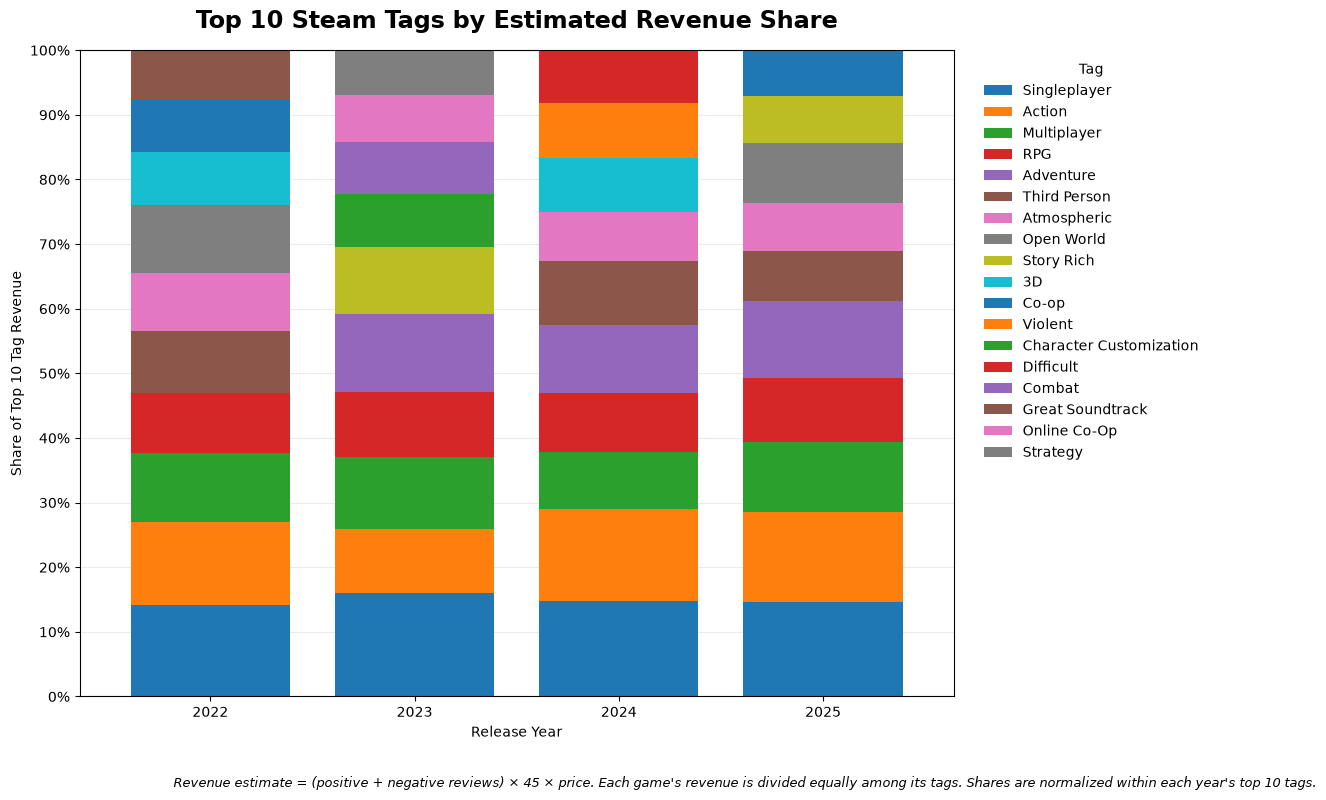

In [37]:
tag_share_pivot = (
    top_tags_by_year
    .pivot(
        index="release_year",
        columns="tag",
        values="share_percent"
    )
    .fillna(0)
    .sort_index()
)

# Order columns by total share across all displayed years
tag_order = (
    tag_share_pivot
    .sum(axis=0)
    .sort_values(ascending=False)
    .index
)

tag_share_pivot = tag_share_pivot[tag_order]

ax = tag_share_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 8),
    width=0.78
)

ax.set_title(
    "Top 10 Steam Tags by Estimated Revenue Share",
    fontsize=17,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Share of Top 10 Tag Revenue")

ax.set_ylim(0, 100)

ax.set_yticks(
    range(0, 101, 10)
)

ax.set_yticklabels(
    [f"{value}%" for value in range(0, 101, 10)]
)

ax.legend(
    title="Tag",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

plt.xticks(rotation=0)

plt.figtext(
    0.5,
    0.01,
    (
        f"Revenue estimate = (positive + negative reviews) × "
        f"{REVIEW_MULTIPLIER} × price. "
        "Each game's revenue is divided equally among its tags. "
        "Shares are normalized within each year's top 10 tags."
    ),
    ha="center",
    fontsize=9,
    style="italic",
    wrap=True
)

plt.tight_layout(
    rect=[0, 0.05, 0.82, 1]
)

plt.show()

In [38]:
yearly_revenue = (
    games_revenue
    .groupby("release_year", as_index=False)
    .agg(
        estimated_revenue=("estimated_revenue", "sum")
    )
    .sort_values("release_year")
)

yearly_revenue

,release_year,estimated_revenue
0,2022,5.237302e+09
1,2023,5.760460e+09
2,2024,1.056352e+10
3,2025,2.907246e+09


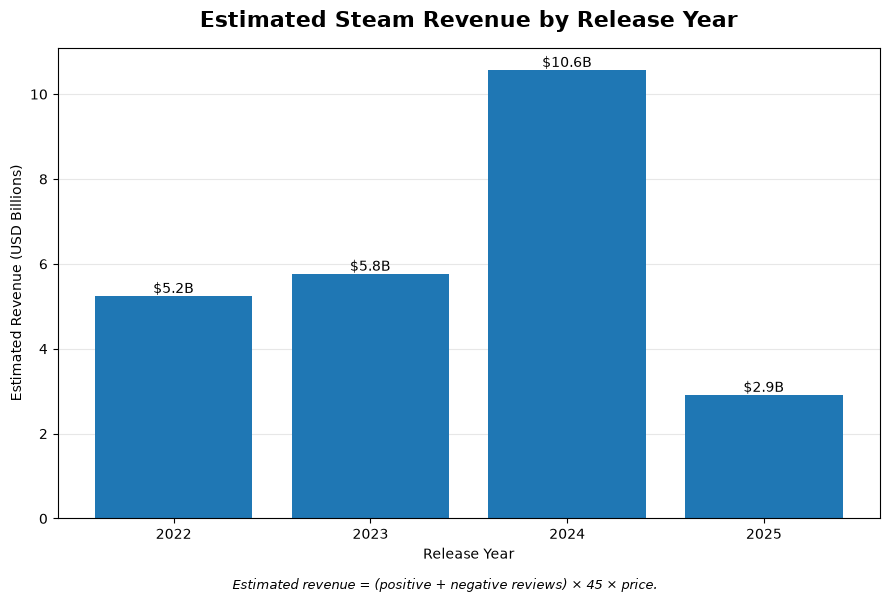

In [39]:
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    yearly_revenue["release_year"].astype(str),
    yearly_revenue["estimated_revenue"] / 1e9
)

ax.set_title(
    "Estimated Steam Revenue by Release Year",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Estimated Revenue (USD Billions)")

ax.grid(
    axis="y",
    alpha=0.3
)

ax.set_axisbelow(True)

# Labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"${height:.1f}B",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.figtext(
    0.5,
    0.01,
    (
        f"Estimated revenue = (positive + negative reviews) × "
        f"{REVIEW_MULTIPLIER} × price."
    ),
    ha="center",
    fontsize=9,
    style="italic"
)

plt.tight_layout(rect=[0, 0.03, 1, 1])

plt.show()

In [42]:
summary = (
    games_revenue
    .groupby("release_year")
    .agg(
        games=("appid", "count"),
        reviews=("total_reviews", "sum"),
        avg_reviews=("total_reviews", "mean"),
        median_reviews=("total_reviews", "median"),
        avg_price=("price", "mean"),
        revenue=("estimated_revenue", "sum")
    )
)

summary

,games,reviews,avg_reviews,median_reviews,avg_price,revenue
release_year,,,,,,
2022,12288,8570998,697.509603,6.0,4.718332,5.237302e+09
2023,14603,8161692,558.905156,4.0,4.999075,5.760460e+09
2024,20042,10061494,502.020457,3.0,5.070325,1.056352e+10
2025,24976,3284048,131.488149,0.0,5.078750,2.907246e+09


In [43]:
zero_review_games = (
    games_revenue
    .assign(
        total_reviews=lambda d: d["positive"] + d["negative"]
    )
    .groupby("release_year")
    .agg(
        total_games=("appid", "count"),
        zero_review_games=("total_reviews", lambda x: (x == 0).sum())
    )
)

zero_review_games["percent_zero"] = (
    zero_review_games["zero_review_games"]
    / zero_review_games["total_games"]
    * 100
)

zero_review_games

,total_games,zero_review_games,percent_zero
release_year,,,
2022,12288,3623,29.484049
2023,14603,4902,33.568445
2024,20042,7598,37.910388
2025,24976,19104,76.489430
